# MLE deconvolver

The aim of this notebook is to implement and test different flavours of the MLE (maximul likelihood estimation) deconvolver

## Imports

In [1]:
from pathlib import Path
import sys
import warnings
from contextlib import contextmanager

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from tqdm.notebook import tqdm
from scipy.optimize import minimize

sys.path.append("../")

from edautils import plot_deconvolution_results
from syto.deconvolution.evaluation import compute_deconvolution_metrics
from syto.data.atlases.uxm_atlases import UXMMethylationAtlas
from baselines.deconvolution.uxm import UXMDeconvolver

## Miscellaneous functions

In [2]:
@contextmanager
def SilenceValueOOBWarning():
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="Values in x were outside bounds during a minimize step",
            category=RuntimeWarning,
        )
        yield

In [3]:
def plot_mixtures_pred_vs_true(
    ground_truth_mixture: np.ndarray,
    predicted_mixtures: list[np.ndarray],
    predicted_mixture_labels: list[str],
    width: float = 0.2,
    title: str = "Predicted Mixtures vs Ground Truth Mixture",
    ctype_names: list[str] = None,
):
    """
    Plot the predicted mixtures against the ground truth mixture for a single sample.
    The function creates a bar plot where the x axis represents the cell types and the y axis represents the mixture proportions.
    Each predicted mixture is plotted as a separate bar. The ground truth mixture is plotted as red dots for each cell type.

    Args:
        ground_truth_mixture: A 1D array of shape (n_cell_types,) representing the true mixture proportions.
        predicted_mixtures: A list of 1D arrays, each of shape (n_cell_types,), representing the predicted mixture proportions from different models.
        predicted_mixture_labels: A list of strings representing the labels for each predicted mixture (e.g., model names).
    """
    assert len(predicted_mixtures) == len(
        predicted_mixture_labels
    ), "Number of predicted mixtures must match number of labels"
    assert all(
        pred.shape == ground_truth_mixture.shape for pred in predicted_mixtures
    ), "All predicted mixtures must have the same shape as the ground truth mixture"
    plt.figure(figsize=(8, 6))
    n_cell_types = len(ground_truth_mixture)
    n_predicted_mixtures = len(predicted_mixtures)
    x = np.arange(n_cell_types)  # start of the the label locations
    x_center = (
        x + width * (n_predicted_mixtures - 1) / 2
    )  # middle of the group of bars for each cell type

    # Plot the ground truth mixture as red dots
    plt.scatter(
        x_center, ground_truth_mixture, color="red", zorder=-1, label="Ground Truth"
    )

    # Plot each predicted mixture as a bar
    for i, (predicted_mixture, label) in enumerate(
        zip(predicted_mixtures, predicted_mixture_labels)
    ):
        plt.bar(x + i * width, predicted_mixture, width, label=label, alpha=0.7)

    # plot the cell types names on the x axis, rotated by 90 degrees
    if ctype_names is not None:
        plt.xticks(x_center, ctype_names, rotation=90)
    plt.ylabel("Mixture Proportions")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

## Data loading and preprocessing

Here we load the predictions for every read and we create 1000 pseudobulks in the same manner as the production pipeline.

In [4]:
with open("../App/labels_dict.json", "r") as f:
    labels_dict = json.load(f)
labels_dict_reversed = {v: int(k) for k, v in labels_dict.items()}

In [5]:
# Soft labels with pooling
soft_labels_test_split = pickle.load(
    open(
        "/staging/leuven/stg_00118/gbw-d-l0154/mnt/data/syto_experiments/mlflow/198121009408531961/e21d054a7dc04dd2a7e8de4231efaa56/artifacts/test_predicted.pkl",
        "rb",
    )
)

In [6]:
# load the predicted reads for the focal loss model
hard_labels_focal_loss_test_split = pickle.load(
    open(
        "/staging/leuven/stg_00118/gbw-d-l0154/mnt/data/syto_experiments/mlflow/408143641137358643/c37d705cbfad44ab9418d275dafe09c3/artifacts/test_predicted.pkl",
        "rb",
    )
)

In [7]:
# load the predicted reads for the hard labels model (w/ background and minibatch balancing)
HARD_LABELS_MINIBATCH_PATH = Path(
    "/staging/leuven/stg_00118/gbw-d-l0154/mnt/data/syto_experiments/mlflow/198121009408531961/a3f1f111ffc14085bc70c8bf60a78e4d/artifacts"
)
hard_labels_minibatch_train_split = pickle.load(
    open(HARD_LABELS_MINIBATCH_PATH / "train_predicted.pkl", "rb")
)
hard_labels_minibatch_test_split = pickle.load(
    open(HARD_LABELS_MINIBATCH_PATH / "test_predicted.pkl", "rb")
)

In [8]:
# load the predicted reads for MethylBert trained on Binary labels with focal loss
binary_labels_focal_loss_test_split = pickle.load(
    open(
        "/staging/leuven/stg_00118/gbw-d-l0154/mnt/data/syto_experiments/mlflow/408143641137358643/5749da69d6a34b4bb10580fb699e1d2b/artifacts/test_predicted.pkl",
        "rb",
    )
)

In [9]:
uxm_atlas = UXMMethylationAtlas(
    atlas_name="UXM U25",
    reference_genome="hg38",
    atlas_path="/data/leuven/389/vsc38912/Projects/syto/Data/Atlas.U25.l4.hg38.full.tsv",
)

In [10]:
uxm_deconvolver = UXMDeconvolver(atlas=uxm_atlas)

Computing the train prior for hard labels with minibatch balancing:

Let :

- $\pi_c^{(S)}$ the proportions of signal (on-target) reads that are of ctype $c$
- $\pi_c^{(B)}$ the proportions of background (off-target) reads that are of ctype $c$
- $r=0.5$ the ratio of background reads in each minibatch
<!-- - $\alpha$ the fraction of signal read in the data
- $\pi_c = \alpha \pi_c^{(S)} + (1-\alpha) \pi_c^{(B)}$ the overall proportions of reads that are of ctype $c$ -->


Each batch sample $r$ reads from the background distribution and $1-r$ reads from the signal distribution.

Therefore the effective per class train proportion is :
$$
\hat{\pi}_c = r \pi_c^{(B)} + (1-r) \pi_c^{(S)}
$$

In [11]:
# P(c): prior from training data frequencies
train_class_counts = (
    hard_labels_minibatch_train_split["original_label"].value_counts().sort_index()
)
train_on_target_counts = (
    hard_labels_minibatch_train_split[
        (
            hard_labels_minibatch_train_split["dmr_ctype_label"]
            == hard_labels_minibatch_train_split["original_label"]
        )
    ]["original_label"]
    .value_counts()
    .sort_index()
)
train_background_class_counts = (
    hard_labels_minibatch_train_split[
        (
            hard_labels_minibatch_train_split["dmr_ctype_label"]
            != hard_labels_minibatch_train_split["original_label"]
        )
    ]["original_label"]
    .value_counts()
    .sort_index()
)
bg_ratio = 0.5
raw_train_freq_prior = (train_class_counts / train_class_counts.sum()).values
raw_train_on_target_ratio = (
    train_on_target_counts / train_on_target_counts.sum()
).values
raw_train_bg_ratio = (
    train_background_class_counts / train_background_class_counts.sum()
).values
effective_train_prior = (
    bg_ratio * raw_train_bg_ratio + (1 - bg_ratio) * raw_train_on_target_ratio
)

## MLE (methylbert flavour)

In this cell, we describe mathematically the likelihood function that we want to maximize in MLE["methylbert flavour"].

Let $\{(r_i, c_i, g_i)\}_{i \in \{1, \dots, N\}}$ be the set of reads, where $r_i$ is the read, $c_i$ is the cell type, and $g_i$ is the GR group.

Let $\{\mathbf{u}_i\}_{i \in \{1, \dots, n\}}$ be the set of predicted probabilities for every read and every cell type,
where $\mathbf{u}_i$ is a vector of length $C+1$ (number of cell types plus background class) and $u_{i,j}$ is the predicted probability that read $i$ belongs to class $j$.

We assume that the underlying true proportions of the cells are $\mathbf{\theta}= (\theta_1, \dots, \theta_C)$, where $\theta_c$ is the proportion of cell type $c$ in the sample.

Let $R_c = \{ i \mid g_i = c_i \}$ be the set of reads that fall in the GR specific to cell type $c$.

Then the likelihood function that we want to maximize is given by:

\begin{align}
L(\mathbf{\theta}) &= \prod_{c=1}^C \prod_{i \in R_c} P(r_i \mid \theta) \\
&= \prod_{c=1}^C \prod_{i \in R_c} \left[\theta_c P(r_i \mid c) + (1-\theta_c) P(r_i \mid \text{not } c) \right] \\
&= \prod_{c=1}^C \prod_{i \in R_c} \left[\theta_c \frac{P(c \mid r_i)P(r_i)}{P(c)} + (1-\theta_c) \frac{P(\text{not } c \mid r_i)P(r_i)}{P(\text{not } c)} \right] \\
&= \prod_{c=1}^C \prod_{i \in R_c} P(r_i) \left[\theta_c \frac{P(c \mid r_i)}{P(c)} + (1-\theta_c) \frac{1 - P(c \mid r_i)}{1 - P(c)} \right] \\
\end{align}

where $P(c)$ is the prior probability of cell type $c$ in the sample, which we estimate as the proportions of the reads that belong to cell type $c$ in the training data (as in the paper).

In particular, this is NOT the equation 19 which is indicated in the paper, which is highly misleading:
\begin{align}
\tag{methylbert paper, equation 19}
L(\mathbf{\theta}) &= \prod_{c=1}^C \prod_{i \in R_c} \left( \theta_c P(r_i \mid c) + (1 - \theta_c) (1-P(r_i \mid c)) \right) \\
\end{align}



So the likelihood function can be rewritten as:

\begin{align}
L(\mathbf{\theta}) &= \prod_{c=1}^C \prod_{i \in R_c} P(r_i) \left[\theta_c \frac{u_{i,c}}{P(c)} + (1-\theta_c) \frac{1 - u_{i,c}}{1 - P(c)} \right] \\ \\
&= \prod_{c=1}^C \prod_{i \in R_c} P(r_i) \left[\theta_c ( \frac{u_{i,c}}{P(c)} - \frac{1 - u_{i,c}}{1 - P(c)}) + \frac{1 - u_{i,c}}{1 - P(c)} \right] \\ \\
&= \prod_{c=1}^C \prod_{i \in R_c} P(r_i) \left[\theta_c \frac{u_{i,c} - P(c)}{P(c)(1-P(c))} + \frac{1 - u_{i,c}}{1 - P(c)} \right] \\
\end{align}

and

$$
\log L(\mathbf{\theta}) = \sum_{c=1}^C \sum_{i \in R_c} \log \left( \theta_c \frac{u_{i,c} - P(c)}{P(c)(1-P(c))} + \frac{1 - u_{i,c}}{1 - P(c)} \right) +  \sum_{c=1}^C \sum_{i \in R_c} \log P(r_i)
$$


and

$$
\theta^* = \arg\max_{\mathbf{\theta}} \log L(\mathbf{\theta})
$$

In [12]:
def _neg_log_likelihood(theta, coeffs_per_class, constants_per_class):
    """Negative log-likelihood for the methylbert MLE deconvolver."""
    nll = 0.0
    for c, (coeffs, constants) in enumerate(zip(coeffs_per_class, constants_per_class)):
        if coeffs is None:
            continue
        nll -= np.sum(np.log(theta[c] * coeffs + constants))
    return nll


def mle_deconvolver_methylbert_scipy(df: pd.DataFrame, P_c: np.ndarray, n_ctypes: int):
    """MLE deconvolver (methylbert flavour) using scipy.optimize.minimize.

    Maximizes the log-likelihood:
    subject to theta >= 0, sum(theta) = 1."""

    pred_cols = ["prediction_" + str(c) for c in range(n_ctypes)]

    # Precompute coefficients and constants per class
    coeffs_per_class = []
    constants_per_class = []
    for c in range(n_ctypes):
        mask = df["dmr_ctype_label"] == c
        if mask.sum() == 0:
            coeffs_per_class.append(None)
            constants_per_class.append(None)
            continue
        u_ic = df.loc[mask, pred_cols[c]].values
        coeffs_per_class.append((u_ic - P_c[c]) / (P_c[c] * (1 - P_c[c])))
        constants_per_class.append((1 - u_ic) / (1 - P_c[c]))

    result = minimize(
        _neg_log_likelihood,
        x0=np.ones(n_ctypes) / n_ctypes,
        args=(coeffs_per_class, constants_per_class),
        method="SLSQP",
        bounds=[(1e-10, 1 - 1e-10)] * n_ctypes,
        constraints={"type": "eq", "fun": lambda x: np.sum(x) - 1},
    )

    return result.x

### Experiment: MLE["methylbert flavour"] on methylbert binarized


In [33]:
def mle_deconvolver_methylbert_scipy_binarized(
    df: pd.DataFrame, P_c: np.ndarray, n_ctypes: int, single_class: int
):
    """MLE deconvolver (methylbert flavour) using scipy.optimize.minimize.

    df is expected to contain reads of a single class

    Maximizes the log-likelihood:
    subject to theta >= 0, sum(theta) = 1."""

    # pred_cols = ["prediction_" + str(c) for c in range(n_ctypes)]

    # Precompute coefficients and constants per class
    coeffs_per_class = []
    constants_per_class = []
    for c in range(n_ctypes):
        mask = df["dmr_ctype_label"] == c
        if mask.sum() == 0:
            coeffs_per_class.append(None)
            constants_per_class.append(None)
            continue
        # if we are in the dmr which is specific to the single class present in the mixture, we use the "prediction_1" column, otherwise we use the "prediction_0" column
        pred_col = "prediction_0" if c == single_class else "prediction_1"
        u_ic = df.loc[mask, pred_col].values
        # coeffs_per_class.append(2 * u_ic * P_c[c]**-1 - 1)
        # constants_per_class.append(1 - u_ic * P_c[c]**-1)
        coeffs_per_class.append((u_ic - P_c[c]) / (P_c[c] * (1 - P_c[c])))
        constants_per_class.append((1 - u_ic) / (1 - P_c[c]))

    result = minimize(
        _neg_log_likelihood,
        x0=np.ones(n_ctypes) / n_ctypes,
        args=(coeffs_per_class, constants_per_class),
        method="SLSQP",
        bounds=[(1e-10, 1 - 1e-10)] * n_ctypes,
        constraints={"type": "eq", "fun": lambda x: np.sum(x) - 1},
    )

    return result.x

In [35]:
n_ctypes = 39
uniform_prior = np.ones(n_ctypes) / n_ctypes
mle_methylbert_binarized_uniform_preds = np.zeros((n_ctypes, n_ctypes))
for c in tqdm(range(n_ctypes), desc="MLE methylbert (uniform prior)"):
    pure_mixture = binary_labels_focal_loss_test_split[
        binary_labels_focal_loss_test_split["original_label"] == c
    ]
    try:
        with SilenceValueOOBWarning():
            mle_methylbert_binarized_uniform_preds[c] = (
                mle_deconvolver_methylbert_scipy_binarized(
                    pure_mixture, uniform_prior, n_ctypes, single_class=c
                )
            )
    except Exception as e:
        print(f"Error for cell type {c}: {e}")
        mle_methylbert_binarized_uniform_preds[c] = np.ones(n_ctypes) / n_ctypes

mle_methylbert_binarized_train_freq_prior_preds = np.zeros((n_ctypes, n_ctypes))
for c in tqdm(range(n_ctypes), desc="MLE methylbert (train freq prior)"):
    pure_mixture = binary_labels_focal_loss_test_split[
        binary_labels_focal_loss_test_split["original_label"] == c
    ]
    try:
        with SilenceValueOOBWarning():
            mle_methylbert_binarized_train_freq_prior_preds[c] = (
                mle_deconvolver_methylbert_scipy_binarized(
                    pure_mixture, raw_train_freq_prior, n_ctypes, single_class=c
                )
            )
    except Exception as e:
        print(f"Error for cell type {c}: {e}")
        mle_methylbert_binarized_train_freq_prior_preds[c] = (
            np.ones(n_ctypes) / n_ctypes
        )

MLE methylbert (uniform prior):   0%|          | 0/39 [00:00<?, ?it/s]

MLE methylbert (train freq prior):   0%|          | 0/39 [00:00<?, ?it/s]

In [36]:
target_proportions = np.eye(n_ctypes)
metrics_mle_methylbert_binarized_uniform = compute_deconvolution_metrics(
    mle_methylbert_binarized_uniform_preds, target_proportions
)
metrics_mle_methylbert_binarized_train_freq_prior = compute_deconvolution_metrics(
    mle_methylbert_binarized_train_freq_prior_preds, target_proportions
)

In [37]:
print("Metrics for MLE MethylBERT with Uniform Prior:")
print(
    f"R2: {metrics_mle_methylbert_binarized_uniform['r2']*1e2:.2f}\t Loa:[{metrics_mle_methylbert_binarized_uniform['loa_lower']*1e2:.2f},{metrics_mle_methylbert_binarized_uniform['loa_upper']*1e2:.2f}]\t Loa (worst) [{metrics_mle_methylbert_binarized_uniform['worst_class_loa_lower']*1e2:.2f}, {metrics_mle_methylbert_binarized_uniform['worst_class_loa_upper']*1e2:.2f}]\t MAE: {metrics_mle_methylbert_binarized_uniform['mae']*1e3:.2f}\t MSE: {metrics_mle_methylbert_binarized_uniform['mse']*1e4:.2f}\t KL: {metrics_mle_methylbert_binarized_uniform['kl']*1e2:.2f}"
)
print(
    f"{metrics_mle_methylbert_binarized_uniform['r2']*1e2:.2f} & [{metrics_mle_methylbert_binarized_uniform['loa_lower']*1e2:.2f},{metrics_mle_methylbert_binarized_uniform['loa_upper']*1e2:.2f}]& [{metrics_mle_methylbert_binarized_uniform['worst_class_loa_lower']*1e2:.2f}, {metrics_mle_methylbert_binarized_uniform['worst_class_loa_upper']*1e2:.2f}] & {metrics_mle_methylbert_binarized_uniform['mae']*1e3:.2f}&{metrics_mle_methylbert_binarized_uniform['mse']*1e4:.2f}&{metrics_mle_methylbert_binarized_uniform['kl']*1e2:.2f}"
)

print("\nMetrics for MLE MethylBERT with Train Frequency Prior:")
print(
    f"R2: {metrics_mle_methylbert_binarized_train_freq_prior['r2']*1e2:.2f}\t MAE: {metrics_mle_methylbert_binarized_train_freq_prior['mae']*1e3:.2f}\t MSE: {metrics_mle_methylbert_binarized_train_freq_prior['mse']*1e4:.2f}\t KL: {metrics_mle_methylbert_binarized_train_freq_prior['kl']*1e2:.2f}"
)
print(
    f"{metrics_mle_methylbert_binarized_train_freq_prior['r2']*1e2:.2f} & [{metrics_mle_methylbert_binarized_train_freq_prior['loa_lower']*1e2:.2f},{metrics_mle_methylbert_binarized_train_freq_prior['loa_upper']*1e2:.2f}]& [{metrics_mle_methylbert_binarized_train_freq_prior['worst_class_loa_lower']*1e2:.2f}, {metrics_mle_methylbert_binarized_train_freq_prior['worst_class_loa_upper']*1e2:.2f}] & {metrics_mle_methylbert_binarized_train_freq_prior['mae']*1e3:.2f}&{metrics_mle_methylbert_binarized_train_freq_prior['mse']*1e4:.2f}&{metrics_mle_methylbert_binarized_train_freq_prior['kl']*1e2:.2f}"
)

Metrics for MLE MethylBERT with Uniform Prior:
R2: 92.34	 Loa:[-8.58,8.58]	 Loa (worst) [-31.30, 26.70]	 MAE: 7.27	 MSE: 19.15	 KL: 21.63
92.34 & [-8.58,8.58]& [-31.30, 26.70] & 7.27&19.15&21.63

Metrics for MLE MethylBERT with Train Frequency Prior:
R2: 94.76	 MAE: 6.23	 MSE: 13.09	 KL: 16.44
94.76 & [-7.09,7.09]& [-26.80, 23.47] & 6.23&13.09&16.44


In [38]:
mle_methylbert_binarized_uniform_avg_pred_per_ctype = (
    mle_methylbert_binarized_uniform_preds.mean(axis=0)
)
majority_predicted_ctype_uniform = (
    mle_methylbert_binarized_uniform_avg_pred_per_ctype.argmax()
)
print(
    f"Majority predicted cell type (uniform prior): {majority_predicted_ctype_uniform} ({labels_dict[str(majority_predicted_ctype_uniform)]})"
)
print(mle_methylbert_binarized_uniform_avg_pred_per_ctype.max())

Majority predicted cell type (uniform prior): 13 (Endothel)
0.07142335012340599


In [39]:
mle_methylbert_binarized_train_freq_avg_pred_per_ctype = (
    mle_methylbert_binarized_train_freq_prior_preds.mean(axis=0)
)
majority_predicted_ctype_train_freq = (
    mle_methylbert_binarized_train_freq_avg_pred_per_ctype.argmax()
)
print(
    f"Majority predicted cell type (train freq prior): {majority_predicted_ctype_train_freq} ({labels_dict[str(majority_predicted_ctype_train_freq)]})"
)
print(mle_methylbert_binarized_train_freq_avg_pred_per_ctype.max())

Majority predicted cell type (train freq prior): 12 (Dermal-Fibro)
0.032987882343405876


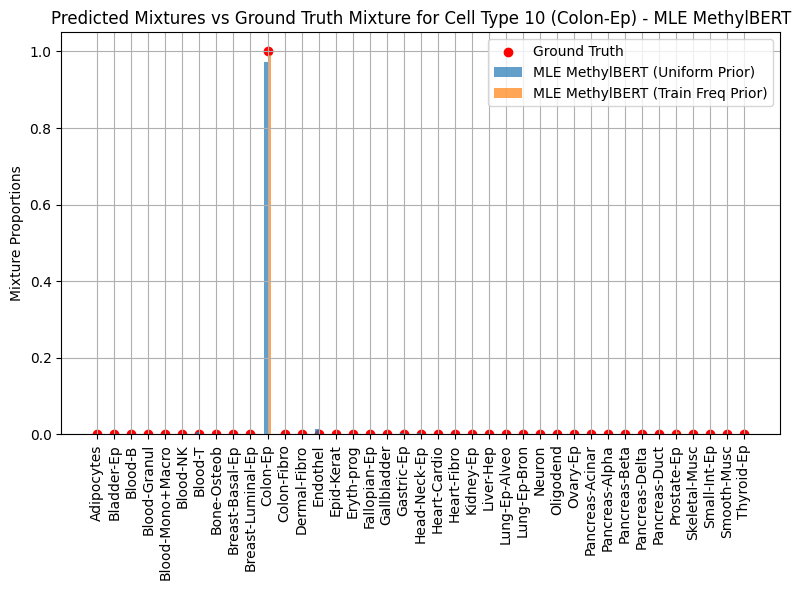

In [40]:
focus_ctype = 10
plot_mixtures_pred_vs_true(
    ground_truth_mixture=target_proportions[focus_ctype],
    predicted_mixtures=[
        mle_methylbert_binarized_uniform_preds[focus_ctype],
        mle_methylbert_binarized_train_freq_prior_preds[focus_ctype],
    ],
    predicted_mixture_labels=[
        "MLE MethylBERT (Uniform Prior)",
        "MLE MethylBERT (Train Freq Prior)",
    ],
    ctype_names=[labels_dict[str(c)] for c in range(n_ctypes)],
    title=f"Predicted Mixtures vs Ground Truth Mixture for Cell Type {focus_ctype} ({labels_dict[str(focus_ctype)]}) - MLE MethylBERT",
)

### Experiments: on pure mixture: UXM & MLE[methylbert flavour] on Methylbert outputs with focal loss

In [14]:
# Effective train prior for the focal loss model
raw_train_freq_prior_fl = hard_labels_minibatch_train_split[
    "original_label"
].value_counts().sort_index() / len(hard_labels_minibatch_train_split)

In [ ]:
n_ctypes = 39
target_proportions = np.eye(n_ctypes)
uniform_prior = np.ones(n_ctypes) / n_ctypes
all_predictions_fl = {}

# MLE methylbert with uniform prior
mle_uniform_preds = np.zeros((n_ctypes, n_ctypes))
for c in tqdm(range(n_ctypes), desc="MLE methylbert (uniform prior)"):
    pure_mixture = hard_labels_focal_loss_test_split[
        hard_labels_focal_loss_test_split["original_label"] == c
    ]
    try:
        with SilenceValueOOBWarning():
            mle_uniform_preds[c] = mle_deconvolver_methylbert_scipy(
                pure_mixture, uniform_prior, n_ctypes
            )
    except Exception as e:
        print(f"Error for cell type {c}: {e}")
        mle_uniform_preds[c] = np.ones(n_ctypes) / n_ctypes
all_predictions_fl["mle_methylbert_uniform"] = mle_uniform_preds

# MLE methylbert with raw train prior
mle_eff_preds = np.zeros((n_ctypes, n_ctypes))
for c in tqdm(range(n_ctypes), desc="MLE methylbert (raw train prior)"):
    pure_mixture = hard_labels_focal_loss_test_split[
        hard_labels_focal_loss_test_split["original_label"] == c
    ]
    try:
        with SilenceValueOOBWarning():
            mle_eff_preds[c] = mle_deconvolver_methylbert_scipy(
                pure_mixture, raw_train_freq_prior_fl, n_ctypes
            )
    except Exception as e:
        print(f"Error for cell type {c}: {e}")
        mle_eff_preds[c] = np.ones(n_ctypes) / n_ctypes
all_predictions_fl["mle_methylbert_raw_train"] = mle_eff_preds

MLE methylbert (uniform prior):   0%|          | 0/39 [00:00<?, ?it/s]

MLE methylbert (raw train prior):   0%|          | 0/39 [00:00<?, ?it/s]

UXM deconvolution:   0%|          | 0/39 [00:00<?, ?it/s]

KeyError: "Column(s) ['record_M', 'record_U', 'record_X'] do not exist"

In [24]:
# UXM
uxm_preds_fl = np.zeros((n_ctypes, n_ctypes))
sample_name = "pure_sample"
for c in tqdm(range(n_ctypes), desc="UXM deconvolution"):
    df_c = hard_labels_focal_loss_test_split[
        hard_labels_focal_loss_test_split["original_label"] == c
    ].copy()
    uxm_preds_fl[c] = uxm_deconvolver.deconvolute_reads(
        reads=df_c, labels_dict_reversed=labels_dict_reversed
    )
all_predictions_fl["uxm"] = uxm_preds_fl

UXM deconvolution:   0%|          | 0/39 [00:00<?, ?it/s]

In [26]:
# Compute and display metrics
class_names = [labels_dict[str(i)] for i in range(n_ctypes)]
deconv_display = {
    "mle_methylbert_uniform": "MLE[methylbert] (uniform prior)",
    "mle_methylbert_raw_train": "MLE[methylbert] (raw train prior)",
    "uxm": "UXM",
}

all_metrics_fl = {}
for name, pred in all_predictions_fl.items():
    m = compute_deconvolution_metrics(
        pred=pred, target=target_proportions, class_names=class_names
    )
    all_metrics_fl[name] = m
    print(
        f"{deconv_display[name]:45s}  R²={m['r2']:.4f}  MAE={m['mae']:.6f}  MSE={m['mse']:.6f}  KL={m['kl']:.4f}  cosine_sim={m['cosine_sim']:.4f}"
    )

MLE[methylbert] (uniform prior)                R²=-0.1029  MAE=0.049092  MSE=0.027555  KL=13.1322  cosine_sim=0.1051
MLE[methylbert] (raw train prior)              R²=-0.0802  MAE=0.049076  MSE=0.026987  KL=11.6660  cosine_sim=0.1114
UXM                                            R²=0.9869  MAE=0.003742  MSE=0.000327  KL=0.0786  cosine_sim=0.9979


In [28]:
# LaTeX table output
deconv_order_fl = ["mle_methylbert_uniform", "mle_methylbert_raw_train", "uxm"]
n_deconv = len(deconv_order_fl)

lines = []
for i, dec in enumerate(deconv_order_fl):
    m = all_metrics_fl[dec]
    r2 = f"{m['r2'] * 100:.2f}"
    loa = f"[{m['loa_lower']*1e2:.2f}, {m['loa_upper']*1e2:.2f}]"
    loa_worst = (
        f"[{m['worst_class_loa_lower']*1e2:.2f}, {m['worst_class_loa_upper']*1e2:.2f}]"
    )
    mae = f"{m['mae']*1e3:.2f}"
    mse = f"{m['mse']*1e4:.2f}"
    kl = f"{m['kl']*1e2:.2f}"
    label = deconv_display[dec]

    if i == 0:
        lines.append(
            f"\\multirow{{{n_deconv}}}{{*}}{{Pure}}"
            f" & {label:<45s} & {r2:<17s} & {loa:<19s} & {loa_worst:<23s} & {mae:<12s} & {mse:<12s} & {kl} \\\\"
        )
    else:
        lines.append(
            f"{'':30s} & {label:<45s} & {r2:<17s} & {loa:<19s} & {loa_worst:<23s} & {mae:<12s} & {mse:<12s} & {kl} \\\\"
        )

    if i < n_deconv - 1:
        lines.append("\\cmidrule(l){2-8}")

print("\n".join(lines))

\multirow{3}{*}{Pure} & MLE[methylbert] (uniform prior)               & -10.29            & [-32.55, 32.55]     & [-33.95, 28.82]         & 49.09        & 275.55       & 1313.22 \\
\cmidrule(l){2-8}
                               & MLE[methylbert] (raw train prior)             & -8.02             & [-32.21, 32.21]     & [-27.64, 35.76]         & 49.08        & 269.87       & 1166.60 \\
\cmidrule(l){2-8}
                               & UXM                                           & 98.69             & [-3.54, 3.54]       & [-9.85, 8.46]           & 3.74         & 3.27         & 7.86 \\


In [29]:
for prior_type in ["uniform", "raw_train"]:
    fl_avg_predictions_per_ctype = all_predictions_fl[
        f"mle_methylbert_{prior_type}"
    ].mean(axis=0)
    majority_predicted_ctype = np.argmax(fl_avg_predictions_per_ctype)
    print(
        f"Majority predicted cell type across all pure samples ({prior_type} prior): {majority_predicted_ctype} ({labels_dict[str(majority_predicted_ctype)]}) with average predicted proportion {fl_avg_predictions_per_ctype[majority_predicted_ctype]:.4f}"
    )

Majority predicted cell type across all pure samples (uniform prior): 6 (Blood-T) with average predicted proportion 0.2389
Majority predicted cell type across all pure samples (raw_train prior): 17 (Gallbladder) with average predicted proportion 0.2396


In [30]:
# bias cell type for UXM
uxm_avg_predictions_per_ctype = all_predictions_fl["uxm"].mean(axis=0)
uxm_majority_predicted_ctype = np.argmax(uxm_avg_predictions_per_ctype)
print(
    f"Majority predicted cell type across all pure samples (UXM): {uxm_majority_predicted_ctype} ({labels_dict[str(uxm_majority_predicted_ctype)]}) with average predicted proportion {uxm_avg_predictions_per_ctype[uxm_majority_predicted_ctype]:.4f}"
)

Majority predicted cell type across all pure samples (UXM): 16 (Fallopian-Ep) with average predicted proportion 0.0297


### Experiments: MLE[methylbert flavour] on pure mixtures, on Methylbert outputs with minibatch balancing

In [42]:
n_ctypes = 39
target_proportions = np.eye(n_ctypes)
uniform_prior = np.ones(n_ctypes) / n_ctypes
all_predictions_mb = {}

# MLE methylbert with uniform prior
mle_uniform_preds = np.zeros((n_ctypes, n_ctypes))
for c in tqdm(range(n_ctypes), desc="MLE methylbert (uniform prior)"):
    pure_mixture = hard_labels_minibatch_test_split[
        hard_labels_minibatch_test_split["original_label"] == c
    ]
    try:
        with SilenceValueOOBWarning():
            mle_uniform_preds[c] = mle_deconvolver_methylbert_scipy(
                pure_mixture, uniform_prior, n_ctypes
            )
    except Exception as e:
        print(f"Error for cell type {c}: {e}")
        mle_uniform_preds[c] = np.ones(n_ctypes) / n_ctypes
all_predictions_mb["mle_methylbert_uniform"] = mle_uniform_preds

# MLE methylbert with effective train prior
mle_eff_preds = np.zeros((n_ctypes, n_ctypes))
for c in tqdm(range(n_ctypes), desc="MLE methylbert (effective train prior)"):
    pure_mixture = hard_labels_minibatch_test_split[
        hard_labels_minibatch_test_split["original_label"] == c
    ]
    try:
        with SilenceValueOOBWarning():
            mle_eff_preds[c] = mle_deconvolver_methylbert_scipy(
                pure_mixture, effective_train_prior, n_ctypes
            )
    except Exception as e:
        print(f"Error for cell type {c}: {e}")
        mle_eff_preds[c] = np.ones(n_ctypes) / n_ctypes
all_predictions_mb["mle_methylbert_effective_train"] = mle_eff_preds

MLE methylbert (uniform prior):   0%|          | 0/39 [00:00<?, ?it/s]

MLE methylbert (effective train prior):   0%|          | 0/39 [00:00<?, ?it/s]

In [44]:
# Compute and display metrics
class_names = [labels_dict[str(i)] for i in range(n_ctypes)]
deconv_display_mb = {
    "mle_methylbert_uniform": "MLE[methylbert] (uniform prior)",
    "mle_methylbert_effective_train": "MLE[methylbert] (effective train prior)",
    "uxm": "UXM",
}

all_metrics_mb = {}
for name, pred in all_predictions_mb.items():
    m = compute_deconvolution_metrics(
        pred=pred, target=target_proportions, class_names=class_names
    )
    all_metrics_mb[name] = m
    print(
        f"{deconv_display_mb[name]:45s}  R²={m['r2']:.4f}  MAE={m['mae']:.6f}  MSE={m['mse']:.6f}  KL={m['kl']:.4f}  cosine_sim={m['cosine_sim']:.4f}"
    )

MLE[methylbert] (uniform prior)                R²=0.3312  MAE=0.037834  MSE=0.016708  KL=1.4994  cosine_sim=0.6151
MLE[methylbert] (effective train prior)        R²=0.3956  MAE=0.036820  MSE=0.015100  KL=1.3939  cosine_sim=0.7097


In [46]:
# LaTeX table output
deconv_order_mb = ["mle_methylbert_uniform", "mle_methylbert_effective_train"]
n_deconv = len(deconv_order_mb)

lines = []
for i, dec in enumerate(deconv_order_mb):
    m = all_metrics_mb[dec]
    r2 = f"{m['r2'] * 100:.2f}"
    loa = f"[{m['loa_lower']*1e2:.2f}, {m['loa_upper']*1e2:.2f}]"
    loa_worst = (
        f"[{m['worst_class_loa_lower']*1e2:.2f}, {m['worst_class_loa_upper']*1e2:.2f}]"
    )
    mae = f"{m['mae']*1e3:.2f}"
    mse = f"{m['mse']*1e4:.2f}"
    kl = f"{m['kl']*1e2:.2f}"
    label = deconv_display_mb[dec]

    if i == 0:
        lines.append(
            f"\\multirow{{{n_deconv}}}{{*}}{{Pure}}"
            f" & {label:<45s} & {r2:<17s} & {loa:<19s} & {loa_worst:<23s} & {mae:<12s} & {mse:<12s} & {kl} \\\\"
        )
    else:
        lines.append(
            f"{'':30s} & {label:<45s} & {r2:<17s} & {loa:<19s} & {loa_worst:<23s} & {mae:<12s} & {mse:<12s} & {kl} \\\\"
        )

    if i < n_deconv - 1:
        lines.append("\\cmidrule(l){2-8}")

print("\n".join(lines))

\multirow{2}{*}{Pure} & MLE[methylbert] (uniform prior)               & 33.12             & [-25.34, 25.34]     & [-33.83, 28.73]         & 37.83        & 167.08       & 149.94 \\
\cmidrule(l){2-8}
                               & MLE[methylbert] (effective train prior)       & 39.56             & [-24.09, 24.09]     & [-33.36, 28.75]         & 36.82        & 151.00       & 139.39 \\


In [47]:
for prior_type in ["uniform", "effective_train"]:
    mb_avg_predictions_per_ctype = all_predictions_mb[
        f"mle_methylbert_{prior_type}"
    ].mean(axis=0)
    majority_predicted_ctype = np.argmax(mb_avg_predictions_per_ctype)
    print(
        f"Majority predicted cell type across all pure samples ({prior_type} prior): {majority_predicted_ctype} ({labels_dict[str(majority_predicted_ctype)]}) with average predicted proportion {mb_avg_predictions_per_ctype[majority_predicted_ctype]:.4f}"
    )

Majority predicted cell type across all pure samples (uniform prior): 26 (Neuron) with average predicted proportion 0.2266
Majority predicted cell type across all pure samples (effective_train prior): 26 (Neuron) with average predicted proportion 0.1503


## MLE (with soft labels)

With the same notations as above, we derive another formulation of the likelihood which 
is more general and takes into account the fact that the model outputs a probability
distribution over the cell types for each read, not just a single probability of the read belonging to the cell type of the DMR group it falls in.

\begin{align}
L'(\mathbf{\theta}) &= \prod_{i=1}^N P(r_i \mid \mathbf{\theta}) \\
&= \prod_{i=1}^N \sum_{c=1}^C \theta_c P(r_i \mid c) \\
&= \prod_{i=1}^N \sum_{c=1}^C \theta_c \frac{P(c \mid r_i)P(r_i)}{P(c)} \\
&= \prod_{i=1}^N P(r_i) \sum_{c=1}^C \theta_c \frac{u_{i,c}}{P(c)} \\
\end{align}

hence

\begin{align}
\log L'(\mathbf{\theta}) &= \sum_{i=1}^Nlog P(r_i) + \sum_{i=1}^N log \left( \sum_{c=1}^C \theta_c \frac{u_{i,c}}{P(c)} \right) \\
\theta^* &= \arg\max_{\mathbf{\theta}} \log L'(\mathbf{\theta})
\end{align}

In [48]:
def _nllh_our(theta, coeffs):
    """Negative log-likelihood for our version of the MLE deconvolver."""
    return -np.sum(np.log(np.sum(coeffs * theta, axis=1)))


def mle_deconvolver_our_scipy(df: pd.DataFrame, P_c: np.ndarray, n_ctypes: int):
    """MLE deconvolver (our flavour) using scipy.optimize.minimize.

    Maximizes the log-likelihood
    subject to theta >= 0, sum(theta) = 1."""

    pred_cols = ["prediction_" + str(c) for c in range(n_ctypes)]

    # Precompute coefficients and constants per class per read
    u_ic_matrix = df[pred_cols].values  # shape (n_reads, n_ctypes)
    coeffs = u_ic_matrix / P_c  # shape (n_reads, n_ctypes)

    result = minimize(
        _nllh_our,
        x0=np.ones(n_ctypes) / n_ctypes,
        args=(coeffs,),
        method="SLSQP",
        bounds=[(1e-10, 1 - 1e-10)] * n_ctypes,
        constraints={"type": "eq", "fun": lambda x: np.sum(x) - 1},
    )

    return result.x

In [51]:
# effective train prior
our_estimated_proportions_train = np.zeros((39, 39))
for c in tqdm(range(39)):
    # Create pure mixture of cell type c
    pure_mixture = soft_labels_test_split[soft_labels_test_split["original_label"] == c]
    try:
        with SilenceValueOOBWarning():
            est_props = mle_deconvolver_our_scipy(
                pure_mixture, effective_train_prior, 39
            )
    except Exception as e:
        print(f"Error for cell type {c}: {e}")
        est_props = 42 * np.ones(39)
    our_estimated_proportions_train[c] = est_props

# uniform prior
uniform_prior = np.ones(39) / 39
our_estimated_proportions_uniform = np.zeros((39, 39))
for c in tqdm(range(39)):
    # Create pure mixture of cell type c
    pure_mixture = soft_labels_test_split[soft_labels_test_split["original_label"] == c]
    try:
        with SilenceValueOOBWarning():
            est_props = mle_deconvolver_our_scipy(pure_mixture, uniform_prior, 39)
    except Exception as e:
        print(f"Error for cell type {c}: {e}")
        est_props = 42 * np.ones(39)
    our_estimated_proportions_uniform[c] = est_props

  0%|          | 0/39 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]

In [53]:
mle_general_metrics_train_prior = compute_deconvolution_metrics(
    pred=our_estimated_proportions_train,
    target=our_target_proportions,
    class_names=[labels_dict[str(i)] for i in range(39)],
)
print(
    f"{mle_general_metrics_train_prior["r2"]*1e2:.2f} & [{mle_general_metrics_train_prior["loa_lower"]*1e2:.2f},{mle_general_metrics_train_prior["loa_upper"]*1e2:.2f}]& [{mle_general_metrics_train_prior["worst_class_loa_lower"]*1e2:.2f}, {mle_general_metrics_train_prior["worst_class_loa_upper"]*1e2:.2f}] & {mle_general_metrics_train_prior["mae"]*1e3:.2f}&{mle_general_metrics_train_prior["mse"]*1e4:.2f}&{mle_general_metrics_train_prior["kl"]*1e2:.2f}"
)

-65.15 & [-39.82,39.84]& [-5.10, 152.04] & 48.20&412.61&544.13


In [54]:
mle_general_metrics_uniform_prior = compute_deconvolution_metrics(
    pred=our_estimated_proportions_uniform,
    target=our_target_proportions,
    class_names=[labels_dict[str(i)] for i in range(39)],
)
print(
    f"{mle_general_metrics_uniform_prior["r2"]*1e2:.2f} & [{mle_general_metrics_uniform_prior["loa_lower"]*1e2:.2f},{mle_general_metrics_uniform_prior["loa_upper"]*1e2:.2f}]& [{mle_general_metrics_uniform_prior["worst_class_loa_lower"]*1e2:.2f}, {mle_general_metrics_uniform_prior["worst_class_loa_upper"]*1e2:.2f}] & {mle_general_metrics_uniform_prior["mae"]*1e3:.2f}&{mle_general_metrics_uniform_prior["mse"]*1e4:.2f}&{mle_general_metrics_uniform_prior["kl"]*1e2:.2f}"
)

-20.20 & [-33.97,33.98]& [38.65, 105.00] & 39.46&300.29&253.97


In [55]:
our_estimated_proportions_uniform

array([[1.97941825e-05, 7.12894536e-01, 2.56946127e-04, ...,
        1.88768655e-04, 1.05128461e-05, 2.06103544e-05],
       [2.10063886e-09, 9.92499671e-01, 5.35567620e-09, ...,
        5.11820888e-09, 2.90924736e-09, 1.97469578e-09],
       [2.75895818e-06, 6.02071120e-01, 3.11853425e-01, ...,
        2.30142571e-04, 1.72954789e-06, 5.98075881e-07],
       ...,
       [3.96743021e-06, 7.11719523e-01, 6.17196327e-05, ...,
        2.81918768e-01, 1.39385983e-06, 3.39428951e-05],
       [9.94118993e-07, 6.94999981e-01, 6.01906567e-07, ...,
        5.21242526e-03, 8.62223689e-07, 1.05672487e-06],
       [6.82278053e-06, 7.84414721e-01, 5.74774276e-06, ...,
        6.02246535e-06, 1.03284355e-06, 2.08432469e-01]], shape=(39, 39))

In [61]:
mle_our_train_avg_pred_per_ctype = our_estimated_proportions_train.mean(axis=0)
majority_predicted_ctype_train = mle_our_train_avg_pred_per_ctype.argmax()
print(
    f"Majority predicted cell type (train prior): {majority_predicted_ctype_train} ({labels_dict[str(majority_predicted_ctype_train)]})"
)
print(mle_our_train_avg_pred_per_ctype.max())

Majority predicted cell type (train prior): 12 (Dermal-Fibro)
0.7603656804248576


In [62]:
mle_our_uniform_avg_pred_per_ctype = our_estimated_proportions_uniform.mean(axis=0)
majority_predicted_ctype_uniform = mle_our_uniform_avg_pred_per_ctype.argmax()
print(
    f"Majority predicted cell type (uniform prior): {majority_predicted_ctype_uniform} ({labels_dict[str(majority_predicted_ctype_uniform)]})"
)
print(mle_our_uniform_avg_pred_per_ctype.max())

Majority predicted cell type (uniform prior): 1 (Bladder-Ep)
0.7438436306158224


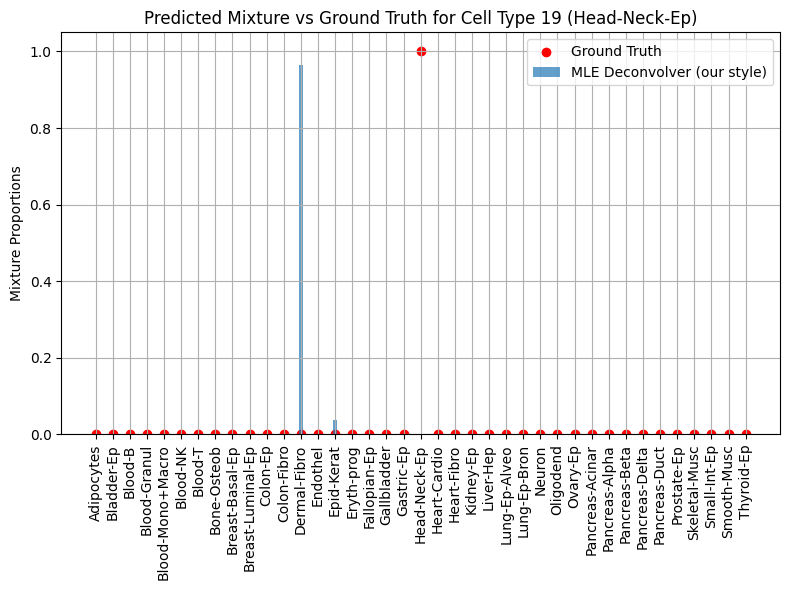

In [60]:
focus_ctype = 19
plot_mixtures_pred_vs_true(
    ground_truth_mixture=our_target_proportions[focus_ctype],
    predicted_mixtures=[our_estimated_proportions[focus_ctype]],
    predicted_mixture_labels=["MLE Deconvolver (our style)"],
    title=f"Predicted Mixture vs Ground Truth for Cell Type {focus_ctype} ({labels_dict[str(focus_ctype)]})",
    ctype_names=[labels_dict[str(i)] for i in range(39)],
)